In [2]:
# Force white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


✅ Plot saved: stress_over_time_per_block.png


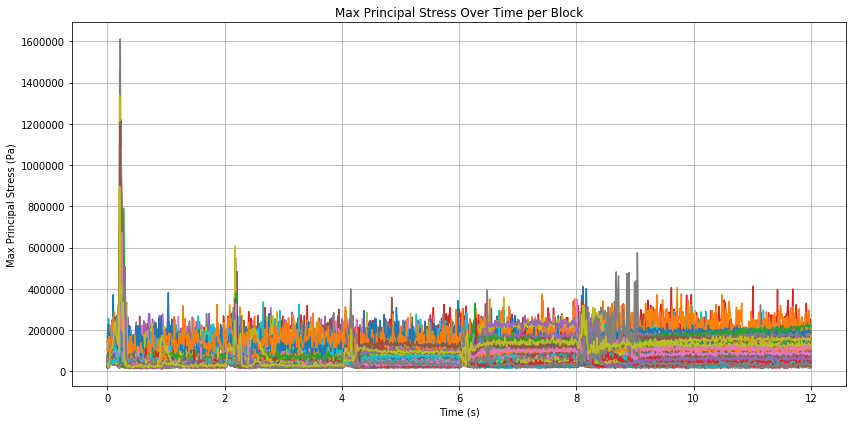

In [3]:

# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd

# --- Load CSV ---
csv_path = 'max_principal_stress_per_block_H06.csv'
df = pd.read_csv(csv_path)

# --- Extract time and block columns ---
time = df['Time']
block_columns = df.columns.drop('Time')
# print(df.head())
# --- Plot ---
plt.figure(figsize=(12, 6))

for block in block_columns:
    plt.plot(time, df[block], label=block)

plt.title("Max Principal Stress Over Time per Block")
plt.xlabel("Time (s)")
plt.ylabel("Max Principal Stress (Pa)")
plt.grid(True)
# plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.tight_layout()
# plt.savefig("stress_over_time_per_block.png")
print("✅ Plot saved: stress_over_time_per_block.png")
plt.show()



✅ Plot saved: stress_over_time_per_block.png


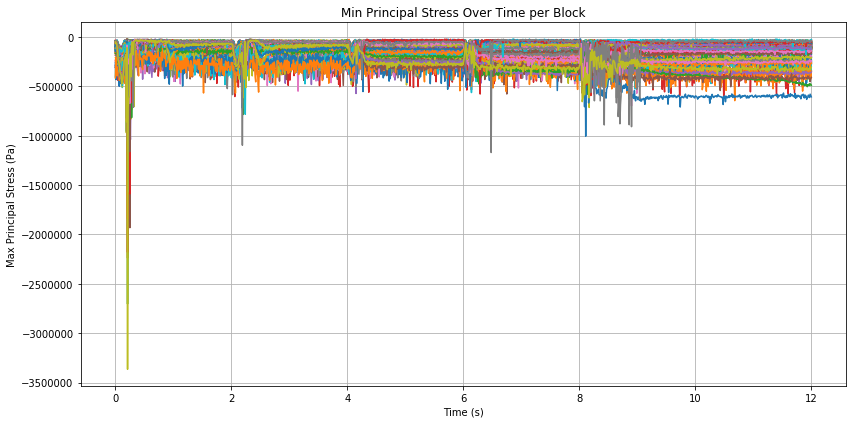

In [9]:

# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd

# --- Load CSV ---
csv_path = 'min_principal_stress_per_block_H06.csv'
df = pd.read_csv(csv_path)

# --- Extract time and block columns ---
time = df['Time']
block_columns = df.columns.drop('Time')
# print(df.head())
# --- Plot ---
plt.figure(figsize=(12, 6))

for block in block_columns:
    plt.plot(time, df[block], label=block)

plt.title("Min Principal Stress Over Time per Block")
plt.xlabel("Time (s)")
plt.ylabel("Max Principal Stress (Pa)")
plt.grid(True)
# plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.tight_layout()
# plt.savefig("stress_over_time_per_block.png")
print("✅ Plot saved: stress_over_time_per_block.png")
plt.show()



✅ Plot saved: stress_over_time_min_max.png


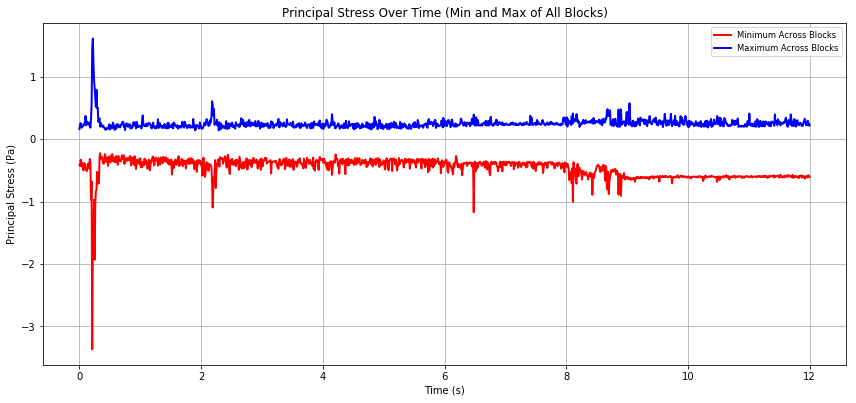

In [14]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd

# --- Load CSVs ---
csv_path_min = 'min_principal_stress_per_block_H06.csv'
csv_path_max = 'max_principal_stress_per_block_H06.csv'

# Load dataframes
df_min = pd.read_csv(csv_path_min)
df_max = pd.read_csv(csv_path_max)

# --- Extract time and block columns ---
time = df_min['Time']           # assuming both CSVs have identical time vectors
block_columns_min = df_min.columns.drop('Time')
block_columns_max = df_max.columns.drop('Time')

# --- Calculate min and max across blocks ---
min_across_blocks = df_min[block_columns_min].min(axis=1)
max_across_blocks = df_max[block_columns_max].max(axis=1)

# --- Plot ---
plt.figure(figsize=(12, 6))

# Plot the minimum line
plt.plot(time, min_across_blocks/1000000, color='red', linewidth=2, label='Minimum Across Blocks')

# Plot the maximum line
plt.plot(time, max_across_blocks/1000000, color='blue', linewidth=2, label='Maximum Across Blocks')

plt.title("Principal Stress Over Time (Min and Max of All Blocks)")
plt.xlabel("Time (s)")
plt.ylabel("Principal Stress (Pa)")
plt.grid(True)
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("stress_over_time_min_max.png")
print("✅ Plot saved: stress_over_time_min_max.png")
plt.show()


✅ Saved: stress_blocks_t6.03s.png


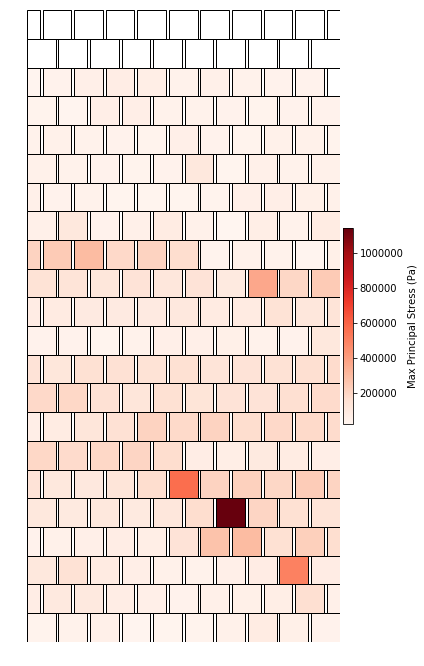

In [7]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.colors as mcolors
import numpy as np

# --- Settings ---
csv_path = 'max_principal_stress_per_block2.csv'
target_time = 6.03  # Time (s) to visualize

# --- Load CSV and get data for time step ---
df = pd.read_csv(csv_path)
df['Time'] = df['Time'].round(2)  # Round time for matching
row = df[df['Time'] == round(target_time, 2)]

if row.empty:
    raise ValueError("⛔ Time step {:.2f} not found in CSV.".format(target_time))

block_data = row.drop(columns='Time').iloc[0]
block_names = block_data.index.tolist()
block_values = block_data.values.astype(float)

# --- Normalize colors ---
norm = mcolors.Normalize(vmin=np.nanmin(block_values), vmax=np.nanmax(block_values))
cmap = plt.cm.Reds

# --- Block layout settings ---
full_w, full_h = 0.5, 0.5
half_w, half_h = 0.225, 0.5
h_spacing = 0.05
v_spacing = 0.0
rows = 22

# --- Initialize plot ---
fig, ax = plt.subplots(figsize=(6, 12))
current_y = 0
block_index = 0

for row_num in range(rows):
    if row_num % 2 == 0:
        # Even rows: 10 full blocks
        for i in range(10):
            x = i * (full_w + h_spacing)
            color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor=color)
            ax.add_patch(rect)
            block_index += 1
    else:
        x = 0
        # First half block
        color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        block_index += 1
        x += half_w + h_spacing
        # 9 full blocks
        for i in range(9):
            color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor=color)
            ax.add_patch(rect)
            block_index += 1
            x += full_w + h_spacing
        # Final half block
        color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        block_index += 1

    current_y += full_h + v_spacing

# --- Format figure ---
ax.set_aspect('equal')
ax.set_xlim(0, x + half_w)
ax.set_ylim(0, current_y)
ax.axis('off')

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label('Max Principal Stress (Pa)')

# --- Save figure ---
plt.tight_layout()
out_name = f"stress_blocks_t{target_time:.2f}s.png"
# plt.savefig(out_name, dpi=300)
print("✅ Saved:", out_name)
plt.show()


Grid width: 4.900 m
MWL (along slope): 14.10 m
✅ Time 2.17 s belongs to Wave 1 in 1000, H=1.58


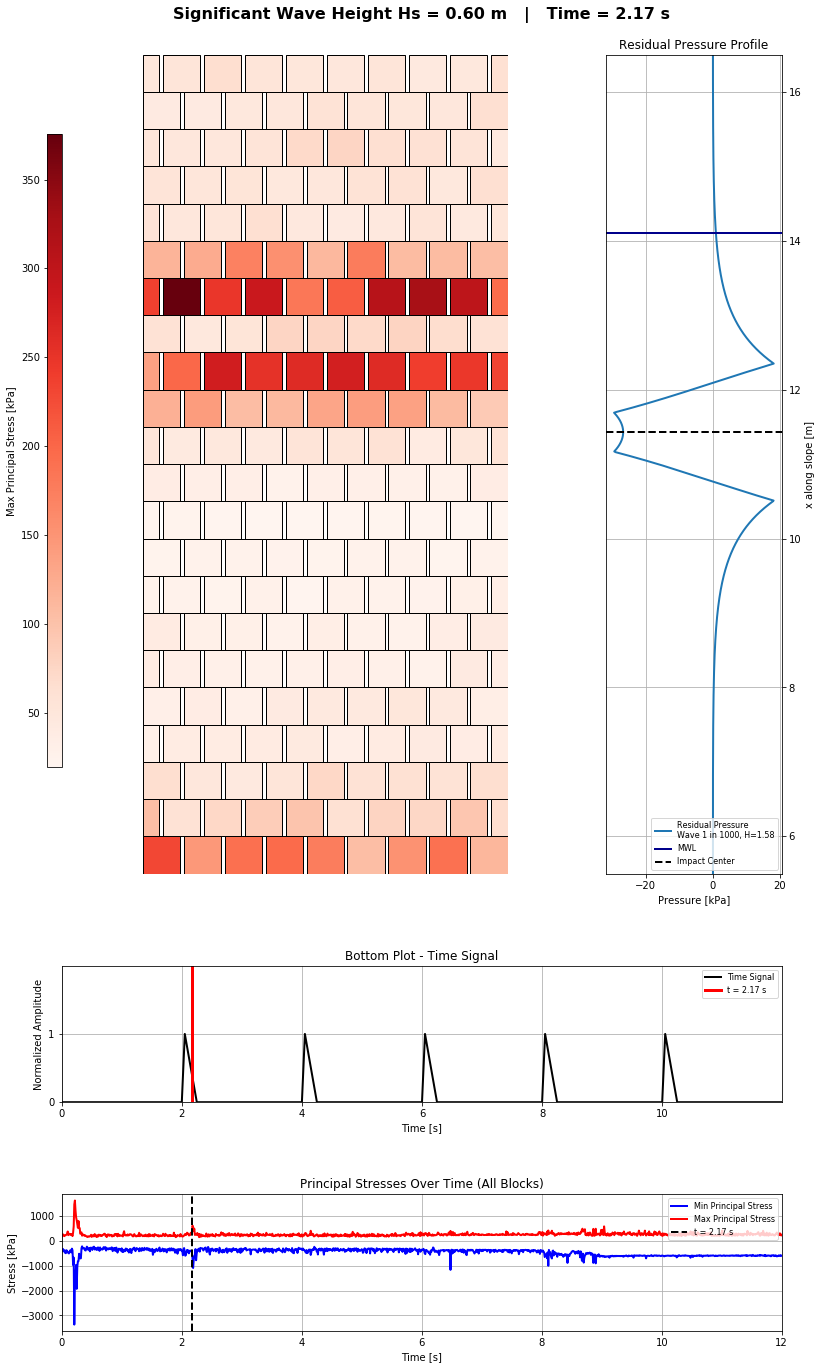

✅ Finished plotting block grid with stresses. Saved as max_principal_stress_per_block_H06_t2.17s.png


In [15]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve

# --- Settings ---
target_time = 2.17  # time in seconds to visualize

# Paths to your stress CSVs
csv_path_min_stress = 'min_principal_stress_per_block_H06.csv'
csv_path_max_stress = 'max_principal_stress_per_block_H06.csv'

# ------------------------------
# Load stress data
# ------------------------------

# Load min and max stress data
df_min_stress = pd.read_csv(csv_path_min_stress)
df_max_stress = pd.read_csv(csv_path_max_stress)

# Round time for consistency
stress_time_col = df_min_stress.columns[0]
df_min_stress[stress_time_col] = df_min_stress[stress_time_col].round(2)
df_max_stress[stress_time_col] = df_max_stress[stress_time_col].round(2)

# Get block columns
block_cols_stress = [c for c in df_min_stress.columns if c.startswith("B-")]

# Compute min/max stress over blocks at each time step
min_stress_over_time = df_min_stress[block_cols_stress].min(axis=1)
max_stress_over_time = df_max_stress[block_cols_stress].max(axis=1)

# --- Extract stress values for the block grid ---
row_stress = df_max_stress[df_max_stress[stress_time_col] == round(target_time, 2)]

if row_stress.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} s not found in stress CSV.")

block_data_stress = row_stress.drop(columns=stress_time_col).iloc[0]

# ------------------------------
# Define brick layout parameters
# ------------------------------

full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0
rows = 22

# Calculate grid width for plotting
grid_width = (9 * full_w) + (8 * horizontal_spacing)
print(f"Grid width: {grid_width:.3f} m")

# ------------------------------
# Create time signal
# ------------------------------

pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

signal = np.zeros_like(time_signal)
for wave in range(total_waves):
    t_start = gravity_time + wave * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal[active] = pulse

df_signal = pd.DataFrame({
    "Time": time_signal,
    "Signal": signal
})

# ------------------------------
# Simulate residual profiles
# ------------------------------

Hs = 0.6
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

x_mwl = SWL / tan_beta
print(f"MWL (along slope): {x_mwl:.2f} m")

block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

# Determine active wave at target time
active_wave = None
for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval
    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    print(f"✅ Time {target_time:.2f} s belongs to {wave_name}")
else:
    print(f"ℹ️ Time {target_time:.2f} s is during gravity loading or after waves.")

# ------------------------------
# Plotting
# ------------------------------

# Adjust layout for 4 plots
gs = gridspec.GridSpec(
    nrows=4,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1, 1, 1],
    wspace=0.05,
    hspace=0.3
)

fig = plt.figure(figsize=(10, 22))

# --- Top left: block grid (STRESS) ---
ax_grid = fig.add_subplot(gs[0, 0])

# Convert stresses to kPa
block_data_stress_kPa = block_data_stress / 1000.0

# Normalize stress color map in kPa
norm_stress = plt.Normalize(
    vmin=np.nanmin(block_data_stress_kPa),
    vmax=np.nanmax(block_data_stress_kPa)
)
cmap_stress = plt.cm.Reds
no_data_color = "lightgray"

for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    is_half = (row_num % 2 == 1)
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [
            (full_w, f"B-{row_num}-{col}") for col in range(1, 10)
        ]

    x_pos = 0.0
    for block_w, block_name in block_sequence:
        if block_name in block_data_stress:
            value = block_data_stress[block_name]
            if np.isnan(value):
                color = no_data_color
            else:
                color = cmap_stress(norm_stress(value / 1000.0))
        else:
            color = no_data_color

        rect = patches.Rectangle(
            (x_pos, current_y),
            block_w, full_h,
            edgecolor='black',
            facecolor=color,
            linewidth=1
        )
        ax_grid.add_patch(rect)
        x_pos += block_w + horizontal_spacing

ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Colorbar for stress in kPa
sm_stress = plt.cm.ScalarMappable(cmap=cmap_stress, norm=norm_stress)
sm_stress.set_array([])
cax_stress = fig.add_axes([-0.02, 0.5, 0.02, 0.4])
cbar_stress = plt.colorbar(sm_stress, cax=cax_stress, orientation='vertical')
cbar_stress.set_label('Max Principal Stress [kPa]')
cbar_stress.ax.yaxis.set_label_position('left')
cbar_stress.ax.yaxis.set_ticks_position('left')

# --- Top right: residual pressure profile ---
ax_side = fig.add_subplot(gs[0, 1])

if active_wave is not None:
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = list(residual_profiles.keys())[0]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

residual_vals_kPa = residual_vals / 1000.0

ax_side.plot(
    residual_vals_kPa,
    x,
    color='#1f77b4',
    linewidth=2,
    label=f"Residual Pressure\n{wave_name}"
)
ax_side.axhline(
    x_mwl,
    color='darkblue',
    linestyle='-',
    linewidth=2,
    label='MWL'
)
ax_side.axhline(
    x_center,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Impact Center'
)
ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [kPa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right', fontsize=8)

# --- Middle: time signal ---
ax_bottom = fig.add_subplot(gs[1, :])
ax_bottom.plot(
    df_signal["Time"],
    df_signal["Signal"],
    color='black',
    linewidth=2,
    label='Time Signal'
)
ax_bottom.axvline(
    target_time,
    color='red',
    linestyle='-',
    linewidth=3,
    label=f"t = {target_time:.2f} s"
)
ax_bottom.set_xlim(0, df_signal["Time"].iloc[-1])
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Normalized Amplitude')
ax_bottom.set_yticks([0, 1])
ax_bottom.set_ylim(0, 2)
ax_bottom.grid(True)
ax_bottom.set_title('Bottom Plot - Time Signal')
ax_bottom.legend(loc='upper right', fontsize=8)

# --- Bottom: stress over time ---
ax_stress = fig.add_subplot(gs[2, :])

min_stress_kPa = min_stress_over_time / 1000.0
max_stress_kPa = max_stress_over_time / 1000.0

ax_stress.plot(
    df_min_stress[stress_time_col],
    min_stress_kPa,
    color='blue',
    linewidth=2,
    label='Min Principal Stress'
)

ax_stress.plot(
    df_max_stress[stress_time_col],
    max_stress_kPa,
    color='red',
    linewidth=2,
    label='Max Principal Stress'
)

ax_stress.axvline(
    target_time,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f"t = {target_time:.2f} s"
)

ax_stress.set_xlabel("Time [s]")
ax_stress.set_xlim(0, 12)
ax_stress.set_ylabel("Stress [kPa]")
ax_stress.set_title("Principal Stresses Over Time (All Blocks)")
ax_stress.legend(loc='upper right', fontsize=8)
ax_stress.grid(True)

# --- Global title ---
fig.suptitle(
    f"Significant Wave Height Hs = {Hs:.2f} m   |   Time = {target_time:.2f} s",
    fontsize=16,
    fontweight="bold"
)

plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)
plt.show()

out_name = csv_path_max_stress.replace(".csv", f"_t{target_time:.2f}s.png")
fig.savefig(csv_path_max_stress.replace(".csv", ".png"), dpi=300, bbox_inches='tight')
print(f"✅ Finished plotting block grid with stresses. Saved as {out_name}")


Grid width: 4.900 m
MWL (along slope): 14.10 m
✅ Time 2.17 s belongs to Wave 1 in 1000, H=1.58


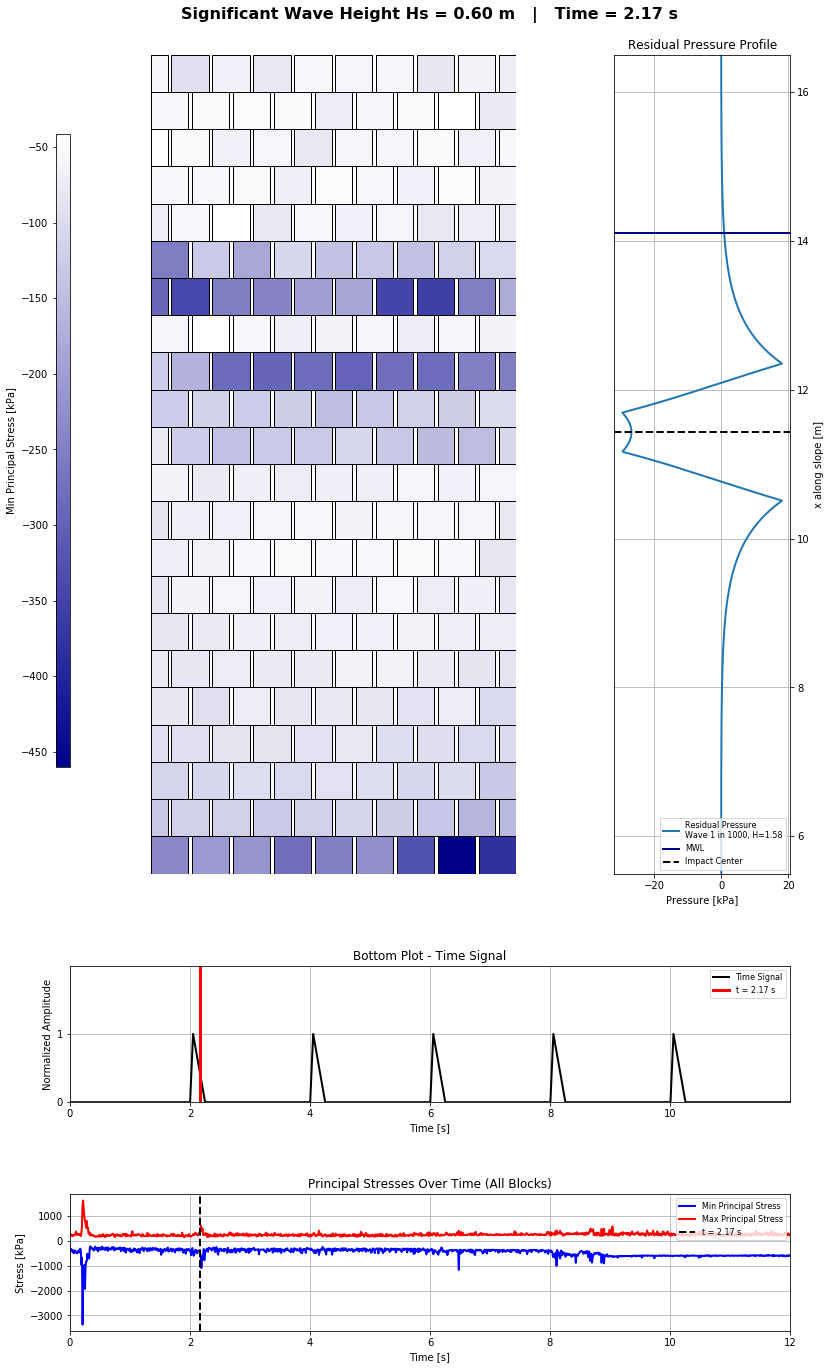

✅ Finished plotting block grid with stresses. Saved as max_principal_stress_per_block_H06_t2.17s.png


In [14]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve

# --- Settings ---
target_time = 2.17  # time in seconds to visualize

# Paths to your stress CSVs
csv_path_min_stress = 'min_principal_stress_per_block_H06.csv'
csv_path_max_stress = 'max_principal_stress_per_block_H06.csv'

# ------------------------------
# Load stress data
# ------------------------------

# Load min and max stress data
df_min_stress = pd.read_csv(csv_path_min_stress)
df_max_stress = pd.read_csv(csv_path_max_stress)

# Round time for consistency
stress_time_col = df_min_stress.columns[0]
df_min_stress[stress_time_col] = df_min_stress[stress_time_col].round(2)
df_max_stress[stress_time_col] = df_max_stress[stress_time_col].round(2)

# Get block columns
block_cols_stress = [c for c in df_min_stress.columns if c.startswith("B-")]

# Compute min/max stress over blocks at each time step
min_stress_over_time = df_min_stress[block_cols_stress].min(axis=1)
max_stress_over_time = df_max_stress[block_cols_stress].max(axis=1)

# --- Extract stress values for the block grid ---
# CHANGED: use min stress instead of max
row_stress = df_min_stress[df_min_stress[stress_time_col] == round(target_time, 2)]

if row_stress.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} s not found in stress CSV.")

block_data_stress = row_stress.drop(columns=stress_time_col).iloc[0]

# ------------------------------
# Define brick layout parameters
# ------------------------------

full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0
rows = 22

# Calculate grid width for plotting
grid_width = (9 * full_w) + (8 * horizontal_spacing)
print(f"Grid width: {grid_width:.3f} m")

# ------------------------------
# Create time signal
# ------------------------------

pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

signal = np.zeros_like(time_signal)
for wave in range(total_waves):
    t_start = gravity_time + wave * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal[active] = pulse

df_signal = pd.DataFrame({
    "Time": time_signal,
    "Signal": signal
})

# ------------------------------
# Simulate residual profiles
# ------------------------------

Hs = 0.6
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

x_mwl = SWL / tan_beta
print(f"MWL (along slope): {x_mwl:.2f} m")

block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

# Determine active wave at target time
active_wave = None
for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval
    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    print(f"✅ Time {target_time:.2f} s belongs to {wave_name}")
else:
    print(f"ℹ️ Time {target_time:.2f} s is during gravity loading or after waves.")

# ------------------------------
# Plotting
# ------------------------------

# Adjust layout for 4 plots
gs = gridspec.GridSpec(
    nrows=4,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1, 1, 1],
    wspace=0.05,
    hspace=0.3
)

fig = plt.figure(figsize=(10, 22))

# --- Top left: block grid (STRESS) ---
ax_grid = fig.add_subplot(gs[0, 0])

# Convert stresses to kPa
block_data_stress_kPa = block_data_stress / 1000.0

# Normalize stress color map in kPa
norm_stress = plt.Normalize(
    vmin=np.nanmin(block_data_stress_kPa),
    vmax=np.nanmax(block_data_stress_kPa)
)

cmap_stress = LinearSegmentedColormap.from_list(
    "white_to_blue",
    [(0, "darkblue"), (1, "white")]
)
no_data_color = "lightgray"

for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    is_half = (row_num % 2 == 1)
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [
            (full_w, f"B-{row_num}-{col}") for col in range(1, 10)
        ]

    x_pos = 0.0
    for block_w, block_name in block_sequence:
        if block_name in block_data_stress:
            value = block_data_stress[block_name]
            if np.isnan(value):
                color = no_data_color
            else:
                color = cmap_stress(norm_stress(value / 1000.0))
        else:
            color = no_data_color

        rect = patches.Rectangle(
            (x_pos, current_y),
            block_w, full_h,
            edgecolor='black',
            facecolor=color,
            linewidth=1
        )
        ax_grid.add_patch(rect)
        x_pos += block_w + horizontal_spacing

ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Colorbar for stress in kPa
sm_stress = plt.cm.ScalarMappable(cmap=cmap_stress, norm=norm_stress)
sm_stress.set_array([])
cax_stress = fig.add_axes([-0.02, 0.5, 0.02, 0.4])
cbar_stress = plt.colorbar(sm_stress, cax=cax_stress, orientation='vertical')
# CHANGED: label to min stress in kPa
cbar_stress.set_label('Min Principal Stress [kPa]')
cbar_stress.ax.yaxis.set_label_position('left')
cbar_stress.ax.yaxis.set_ticks_position('left')

# --- Top right: residual pressure profile ---
ax_side = fig.add_subplot(gs[0, 1])

if active_wave is not None:
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = list(residual_profiles.keys())[0]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

residual_vals_kPa = residual_vals / 1000.0

ax_side.plot(
    residual_vals_kPa,
    x,
    color='#1f77b4',
    linewidth=2,
    label=f"Residual Pressure\n{wave_name}"
)
ax_side.axhline(
    x_mwl,
    color='darkblue',
    linestyle='-',
    linewidth=2,
    label='MWL'
)
ax_side.axhline(
    x_center,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Impact Center'
)
ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [kPa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right', fontsize=8)

# --- Middle: time signal ---
ax_bottom = fig.add_subplot(gs[1, :])
ax_bottom.plot(
    df_signal["Time"],
    df_signal["Signal"],
    color='black',
    linewidth=2,
    label='Time Signal'
)
ax_bottom.axvline(
    target_time,
    color='red',
    linestyle='-',
    linewidth=3,
    label=f"t = {target_time:.2f} s"
)
ax_bottom.set_xlim(0, df_signal["Time"].iloc[-1])
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Normalized Amplitude')
ax_bottom.set_yticks([0, 1])
ax_bottom.set_ylim(0, 2)
ax_bottom.grid(True)
ax_bottom.set_title('Bottom Plot - Time Signal')
ax_bottom.legend(loc='upper right', fontsize=8)

# --- Bottom: stress over time ---
ax_stress = fig.add_subplot(gs[2, :])

min_stress_kPa = min_stress_over_time / 1000.0
max_stress_kPa = max_stress_over_time / 1000.0

ax_stress.plot(
    df_min_stress[stress_time_col],
    min_stress_kPa,
    color='blue',
    linewidth=2,
    label='Min Principal Stress'
)

ax_stress.plot(
    df_max_stress[stress_time_col],
    max_stress_kPa,
    color='red',
    linewidth=2,
    label='Max Principal Stress'
)

ax_stress.axvline(
    target_time,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f"t = {target_time:.2f} s"
)

ax_stress.set_xlabel("Time [s]")
ax_stress.set_xlim(0, 12)
ax_stress.set_ylabel("Stress [kPa]")
ax_stress.set_title("Principal Stresses Over Time (All Blocks)")
ax_stress.legend(loc='upper right', fontsize=8)
ax_stress.grid(True)

# --- Global title ---
fig.suptitle(
    f"Significant Wave Height Hs = {Hs:.2f} m   |   Time = {target_time:.2f} s",
    fontsize=16,
    fontweight="bold"
)

plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)
plt.show()

out_name = csv_path_max_stress.replace(".csv", f"_t{target_time:.2f}s.png")
fig.savefig(csv_path_min_stress.replace(".csv", ".png"), dpi=300, bbox_inches='tight')
print(f"✅ Finished plotting block grid with stresses. Saved as {out_name}")


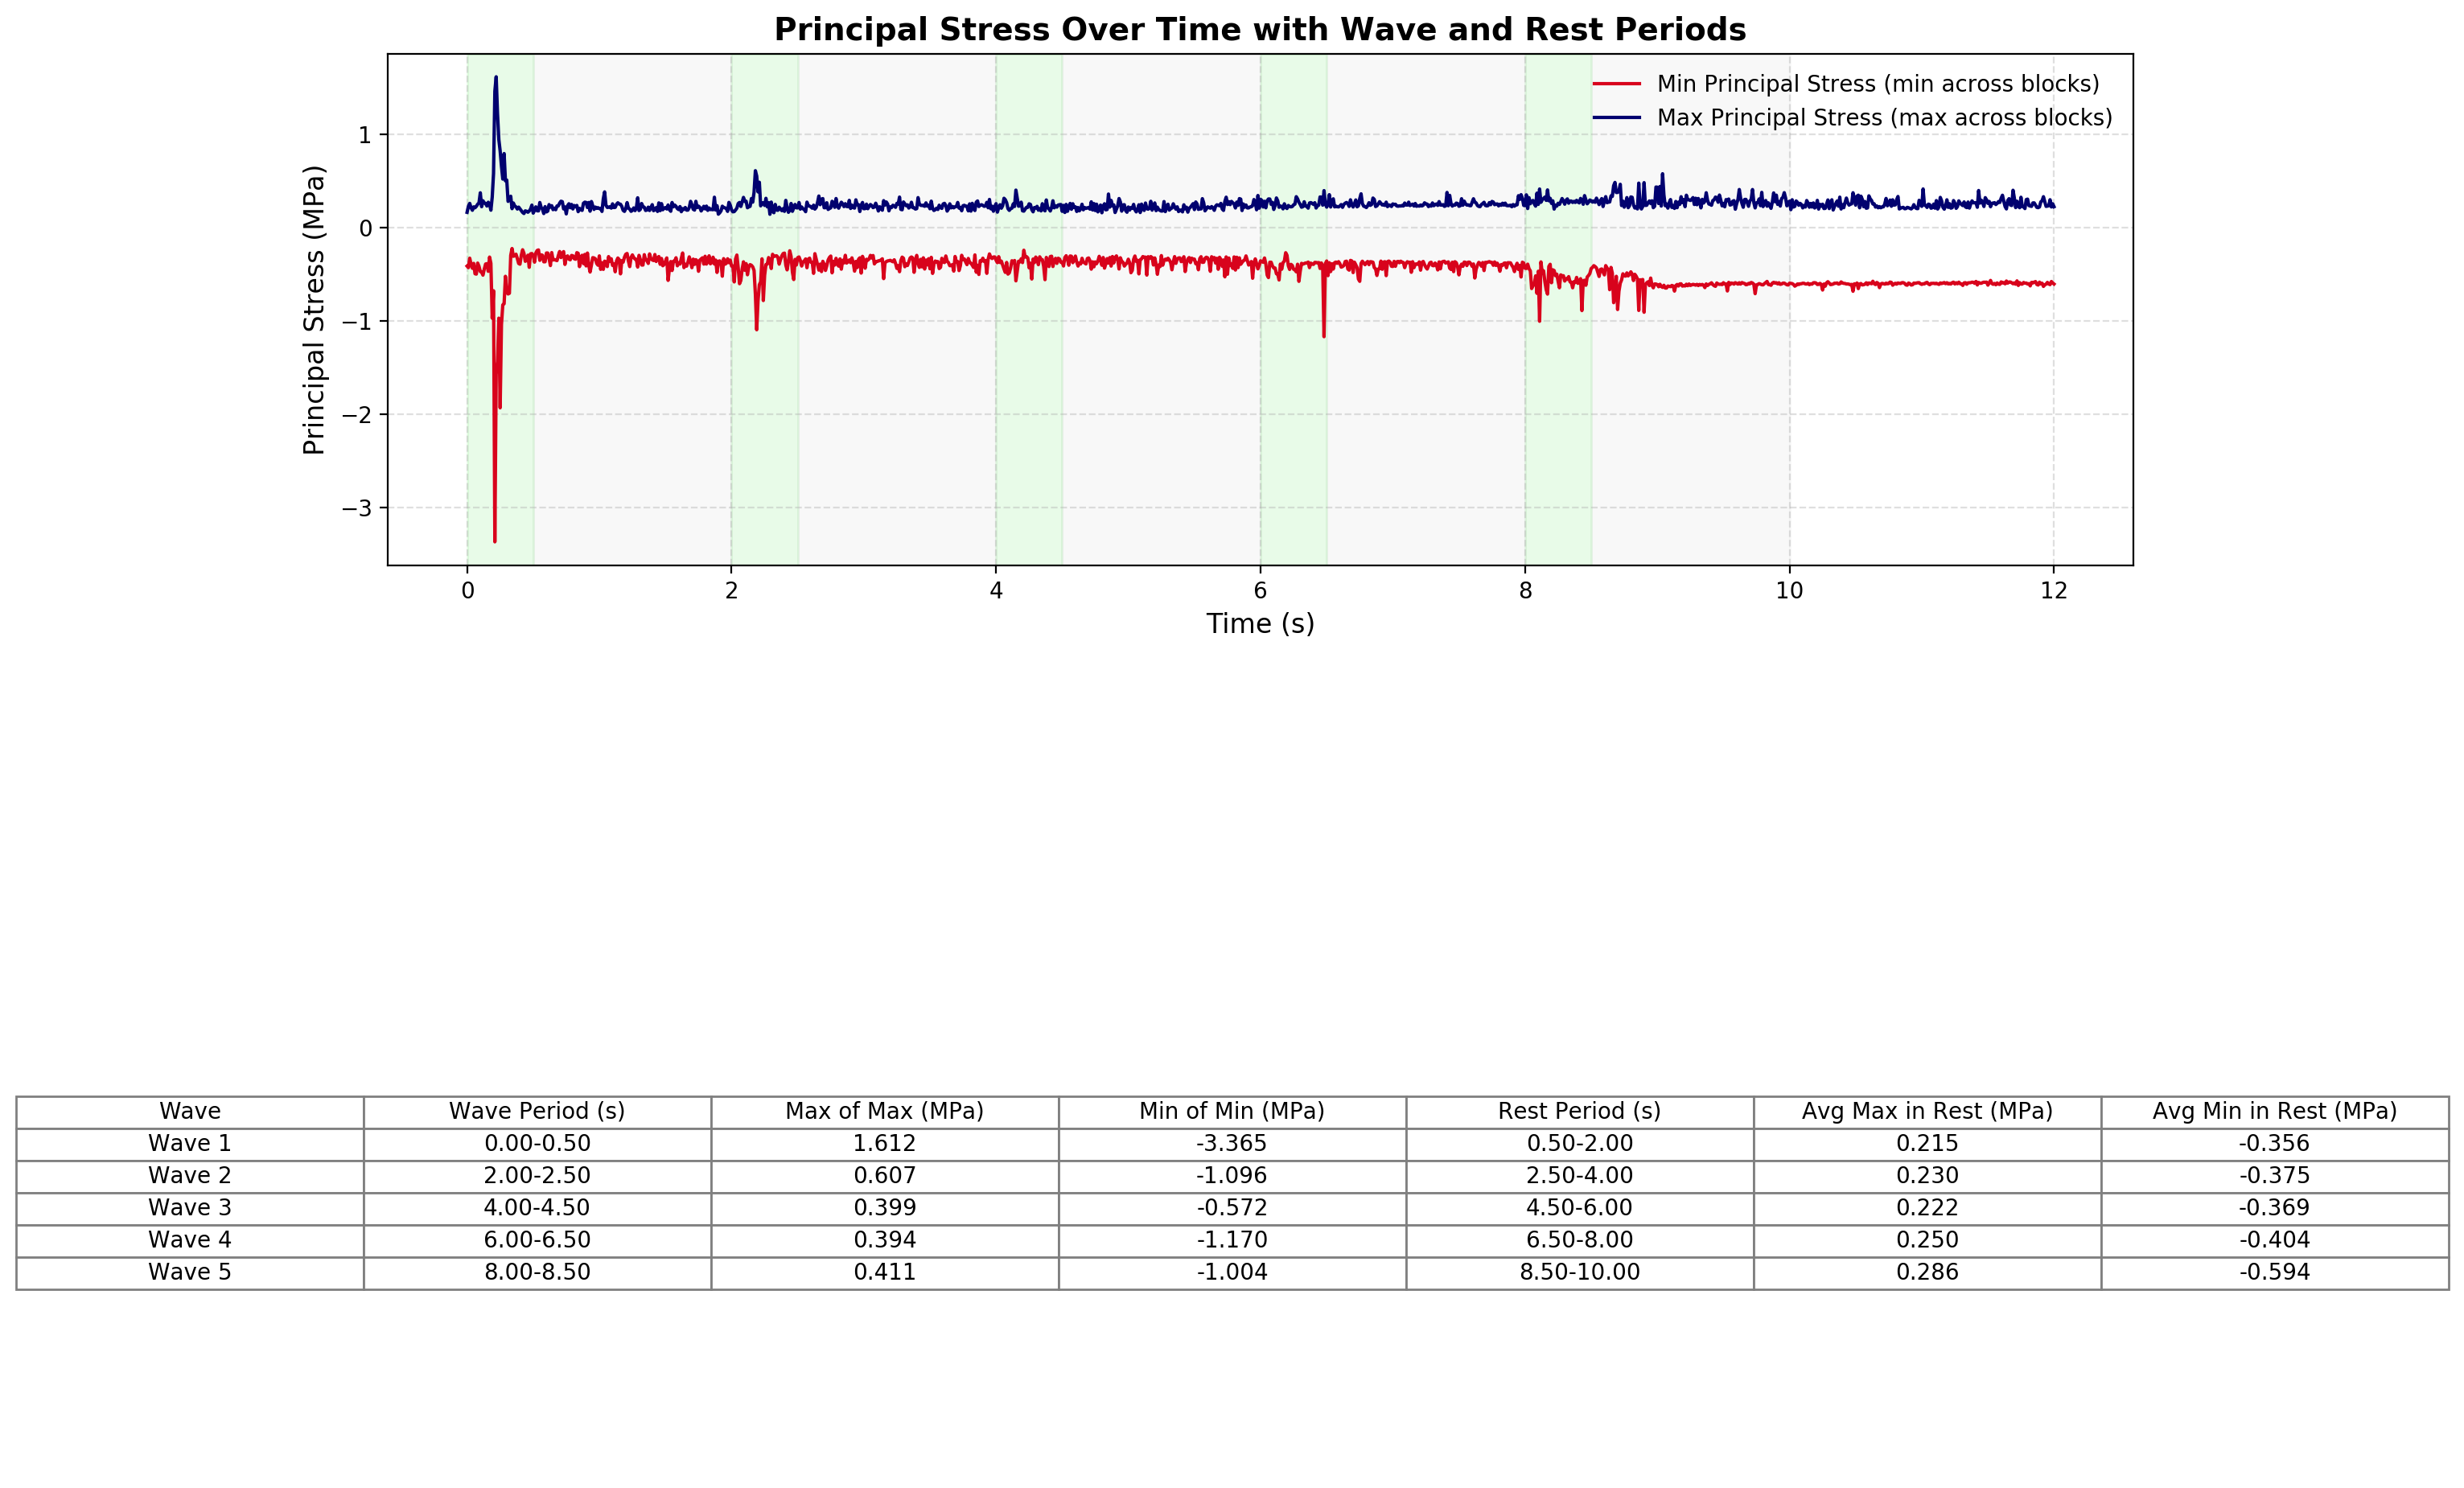


--- Detailed Results ---
Wave 1:
  Wave Period: 0.00-0.50 s
     Max of Max: 1.612 MPa
     Min of Min: -3.365 MPa
  Rest Period: 0.50-2.00 s
     Avg Max in Rest: 0.215 MPa
     Avg Min in Rest: -0.356 MPa

Wave 2:
  Wave Period: 2.00-2.50 s
     Max of Max: 0.607 MPa
     Min of Min: -1.096 MPa
  Rest Period: 2.50-4.00 s
     Avg Max in Rest: 0.230 MPa
     Avg Min in Rest: -0.375 MPa

Wave 3:
  Wave Period: 4.00-4.50 s
     Max of Max: 0.399 MPa
     Min of Min: -0.572 MPa
  Rest Period: 4.50-6.00 s
     Avg Max in Rest: 0.222 MPa
     Avg Min in Rest: -0.369 MPa

Wave 4:
  Wave Period: 6.00-6.50 s
     Max of Max: 0.394 MPa
     Min of Min: -1.170 MPa
  Rest Period: 6.50-8.00 s
     Avg Max in Rest: 0.250 MPa
     Avg Min in Rest: -0.404 MPa

Wave 5:
  Wave Period: 8.00-8.50 s
     Max of Max: 0.411 MPa
     Min of Min: -1.004 MPa
  Rest Period: 8.50-10.00 s
     Avg Max in Rest: 0.286 MPa
     Avg Min in Rest: -0.594 MPa



In [10]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Load CSVs ---
csv_path_min = 'min_principal_stress_per_block_H06.csv'
csv_path_max = 'max_principal_stress_per_block_H06.csv'

# Load dataframes
df_min = pd.read_csv(csv_path_min)
df_max = pd.read_csv(csv_path_max)

# --- Extract time and block columns ---
time = df_min['Time']
block_columns_min = df_min.columns.drop('Time')
block_columns_max = df_max.columns.drop('Time')

# --- Calculate min and max across blocks ---
min_across_blocks = df_min[block_columns_min].min(axis=1)
max_across_blocks = df_max[block_columns_max].max(axis=1)

# --- Define wave windows ---
wave_duration = 0.5
rest_duration = 1.5

wave_starts = [0.0]

# Compute subsequent wave starts
for i in range(1, 5):
    prev_start = wave_starts[-1]
    next_start = prev_start + wave_duration + rest_duration
    wave_starts.append(next_start)

# Create list of (start, end) tuples for waves
wave_periods = [(start, start + wave_duration) for start in wave_starts]

# Create list of (start, end) tuples for rest periods
rest_periods = []
for start, end in wave_periods:
    rest_start = end
    rest_end = rest_start + rest_duration
    # Ensure rest_end is within signal range
    if rest_start < time.max():
        rest_end = min(rest_end, time.max())
        rest_periods.append((rest_start, rest_end))

# --- Analyze waves and rest periods ---
results = []

for i, (wave_start, wave_end) in enumerate(wave_periods):
    # Wave period
    mask_wave = (time >= wave_start) & (time <= wave_end)
    max_max_wave = max_across_blocks[mask_wave].max() / 1e6
    min_min_wave = min_across_blocks[mask_wave].min() / 1e6

    # Corresponding rest period if it exists
    if i < len(rest_periods):
        rest_start, rest_end = rest_periods[i]
        mask_rest = (time > rest_start) & (time <= rest_end)
        avg_max_rest = max_across_blocks[mask_rest].mean() / 1e6
        avg_min_rest = min_across_blocks[mask_rest].mean() / 1e6
    else:
        rest_start, rest_end = None, None
        avg_max_rest, avg_min_rest = None, None

    results.append({
        'Wave': f"Wave {i+1}",
        'Wave Start (s)': wave_start,
        'Wave End (s)': wave_end,
        'Max of Max (MPa)': max_max_wave,
        'Min of Min (MPa)': min_min_wave,
        'Rest Start (s)': rest_start,
        'Rest End (s)': rest_end,
        'Avg Max during Rest (MPa)': avg_max_rest,
        'Avg Min during Rest (MPa)': avg_min_rest
    })

# --- Prepare table data ---
table_data = []
for res in results:
    wave_period = f"{res['Wave Start (s)']:.2f}-{res['Wave End (s)']:.2f}"
    max_max_str = f"{res['Max of Max (MPa)']:.3f}"
    min_min_str = f"{res['Min of Min (MPa)']:.3f}"

    if res['Rest Start (s)'] is not None:
        rest_period = f"{res['Rest Start (s)']:.2f}-{res['Rest End (s)']:.2f}"
        avg_max_rest_str = f"{res['Avg Max during Rest (MPa)']:.3f}"
        avg_min_rest_str = f"{res['Avg Min during Rest (MPa)']:.3f}"
    else:
        rest_period = "-"
        avg_max_rest_str = "-"
        avg_min_rest_str = "-"

    table_data.append([
        res['Wave'],
        wave_period,
        max_max_str,
        min_min_str,
        rest_period,
        avg_max_rest_str,
        avg_min_rest_str
    ])

columns = [
    "Wave",
    "Wave Period (s)",
    "Max of Max (MPa)",
    "Min of Min (MPa)",
    "Rest Period (s)",
    "Avg Max in Rest (MPa)",
    "Avg Min in Rest (MPa)"
]

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6), dpi=200)

# Plot stress curves with custom colors
ax.plot(
    time,
    min_across_blocks / 1e6,
    color='#d8031c',
    linewidth=1.5,
    label='Min Principal Stress (min across blocks)'
)

ax.plot(
    time,
    max_across_blocks / 1e6,
    color='#01016f',
    linewidth=1.5,
    label='Max Principal Stress (max across blocks)'
)

# Shade wave periods
for start, end in wave_periods:
    ax.axvspan(start, end, color='lightgreen', alpha=0.2)

# Shade rest periods
for start, end in rest_periods:
    ax.axvspan(start, end, color='lightgrey', alpha=0.15)

# Labels and style
ax.set_title("Principal Stress Over Time with Wave and Rest Periods", fontsize=14, fontweight='bold')
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Principal Stress (MPa)", fontsize=12)
ax.legend(loc='upper right', fontsize=10, frameon=False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=10)

# --- Add table below plot ---
ax_table = fig.add_axes([0.05, -0.55, 0.9, 0.5])  # left, bottom, width, height
ax_table.axis('off')

table = ax_table.table(
    cellText=table_data,
    colLabels=columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Optional: cell border styling
for key, cell in table.get_celld().items():
    cell.set_edgecolor('grey')

plt.subplots_adjust(bottom=0.35)

plt.show()

# --- Console Output ---
print("\n--- Detailed Results ---")
for res in results:
    print(f"{res['Wave']}:")
    print(f"  Wave Period: {res['Wave Start (s)']:.2f}-{res['Wave End (s)']:.2f} s")
    print(f"     Max of Max: {res['Max of Max (MPa)']:.3f} MPa")
    print(f"     Min of Min: {res['Min of Min (MPa)']:.3f} MPa")
    if res['Rest Start (s)'] is not None:
        print(f"  Rest Period: {res['Rest Start (s)']:.2f}-{res['Rest End (s)']:.2f} s")
        print(f"     Avg Max in Rest: {res['Avg Max during Rest (MPa)']:.3f} MPa")
        print(f"     Avg Min in Rest: {res['Avg Min during Rest (MPa)']:.3f} MPa")
    print("")
